In [1]:
!pip install kagglehub


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 2/2 [kagglehub]



In [2]:
import kagglehub

path = kagglehub.dataset_download("arezaei81/heartcsv")

print("Path to dataset files:", path)

100%|██████████| 3.36k/3.36k [00:00<00:00, 3.74MB/s]

Extracting files...
Path to dataset files: C:\Users\Sohaib\.cache\kagglehub\datasets\arezaei81\heartcsv\versions\1


In [3]:
import os
import pandas as pd

print(os.listdir(path))

['heart.csv']


In [6]:
data = pd.read_csv(os.path.join(path, "heart.csv"))

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# Task 3: Heart Disease Prediction

## Objective
The objective of this task is to build a machine learning model that predicts whether a person is at risk of heart disease based on medical features.

## Dataset
The Heart Disease dataset is downloaded from Kaggle using `kagglehub`.

## Model Used
Logistic Regression is used for binary classification.

## Evaluation Metrics
The model is evaluated using:
- Accuracy
- Confusion Matrix
- ROC Curve
- ROC-AUC Score
- Classification Report

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

print("Libraries imported successfully!")

Libraries imported successfully!


## Loading the Dataset

The dataset is downloaded from Kaggle using kagglehub and then loaded using pandas.

In [10]:
# Download latest version of the Heart Disease dataset
path = kagglehub.dataset_download("arezaei81/heartcsv")

print("Path to dataset files:", path)
print("Files inside dataset folder:", os.listdir(path))

Path to dataset files: C:\Users\Sohaib\.cache\kagglehub\datasets\arezaei81\heartcsv\versions\1
Files inside dataset folder: ['heart.csv']


In [11]:
# Load the CSV file
data = pd.read_csv(os.path.join(path, "heart.csv"))

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Data Inspection

Now we inspect the dataset by checking its shape, columns, first few rows, information, and summary statistics.

In [12]:
print("Shape of dataset:", data.shape)

print("\nColumn names:")
print(data.columns)

print("\nFirst five rows:")
display(data.head())

Shape of dataset: (303, 14)

Column names:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

First five rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [14]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Checking Missing Values

Before training the model, we check if the dataset contains missing values.

In [15]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [16]:
# Remove duplicate rows if any
print("Duplicate rows before removing:", data.duplicated().sum())

data = data.drop_duplicates()

print("Duplicate rows after removing:", data.duplicated().sum())

Duplicate rows before removing: 1
Duplicate rows after removing: 0


## Exploratory Data Analysis

Exploratory Data Analysis helps us understand the dataset through visualizations.

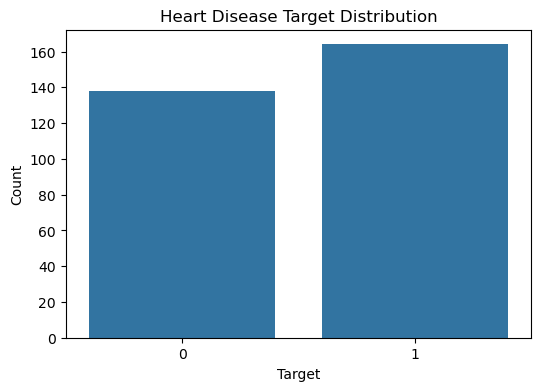

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=data)
plt.title("Heart Disease Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

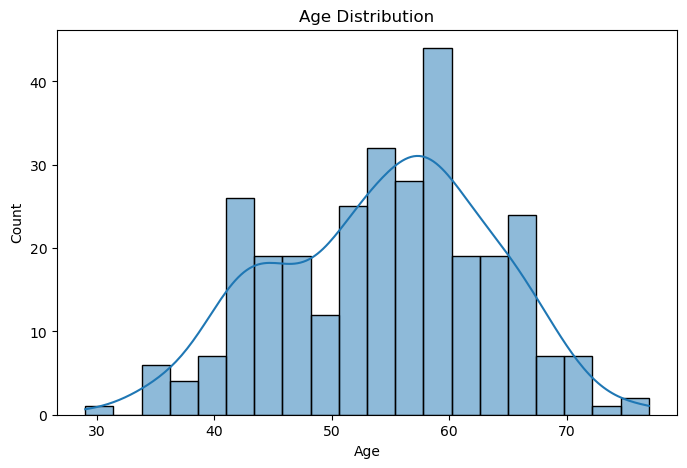

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(data["age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

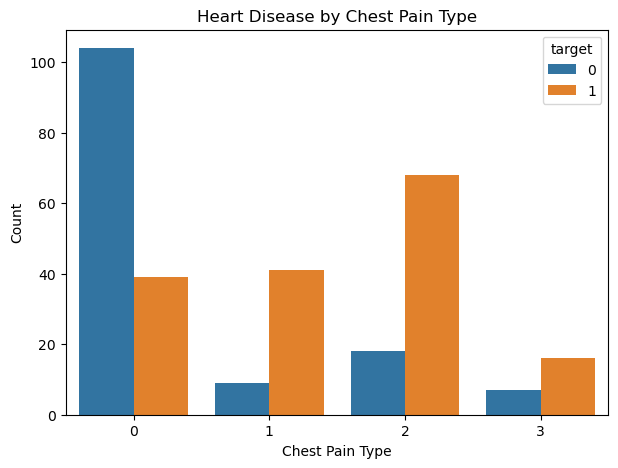

In [19]:
plt.figure(figsize=(7, 5))
sns.countplot(x="cp", hue="target", data=data)
plt.title("Heart Disease by Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.show()

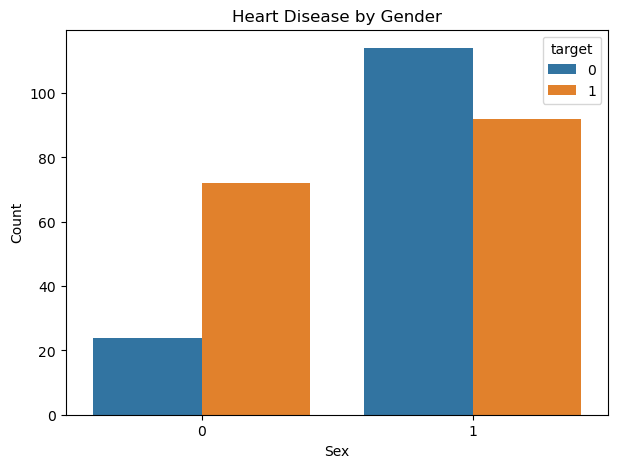

In [20]:
plt.figure(figsize=(7, 5))
sns.countplot(x="sex", hue="target", data=data)
plt.title("Heart Disease by Gender")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

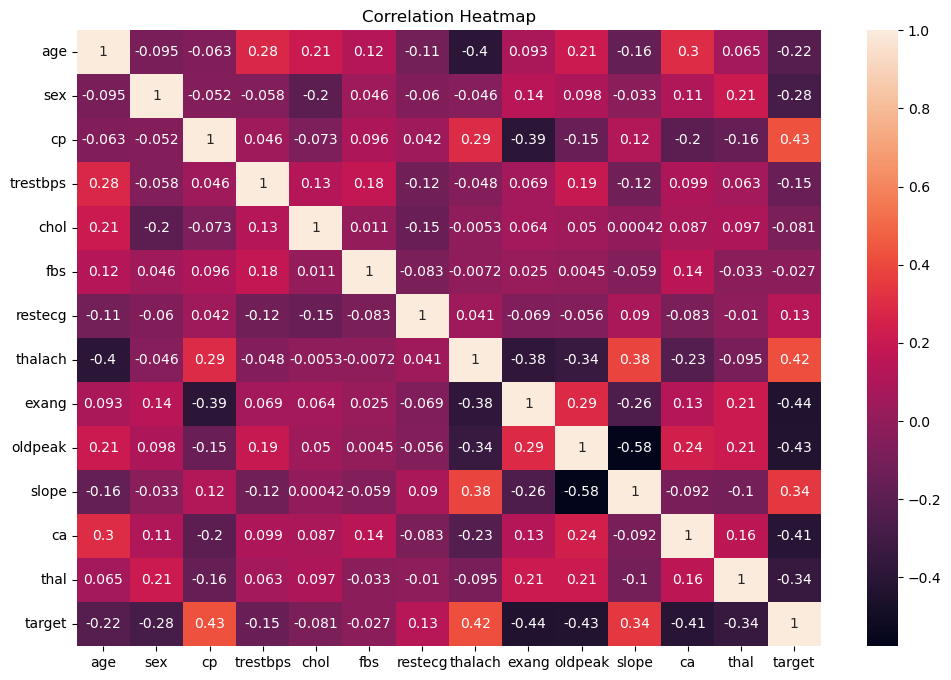

In [21]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Data Preprocessing

The target column is separated from the input features.

In this dataset:
- `target = 1` means the person has heart disease
- `target = 0` means the person does not have heart disease

In [24]:
X = data.drop("target", axis=1)
y = data["target"]

print("Input features shape:", X.shape)
print("Target shape:", y.shape)

Input features shape: (302, 13)
Target shape: (302,)


## Splitting the Dataset

The dataset is divided into training and testing data.

80% of the data is used for training and 20% is used for testing.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (241, 13)
Testing data size: (61, 13)


## Feature Scaling

Logistic Regression performs better when features are scaled.

StandardScaler is used to standardize the feature values.

In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


## Model Training

A Logistic Regression model is trained using the training data.

In [27]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


## Making Predictions

The trained model is used to predict heart disease on the test data.

In [28]:
y_pred = model.predict(X_test_scaled)

predictions = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

predictions.head()

,Actual,Predicted
0,0,0
1,0,0
2,1,1
3,0,0
4,1,1
